**By:** Rafay Siddiqui  
**Student No:** 24K-0009  
**Section:** BAI-4A

# Q1
In the example code above, customer segmentation was performed using only two features. Now, use all available features except customer_id to implement K-Means
clustering. Perform the clustering twice — once without feature scaling, and once with
scaling applied to all features except age. Compare the results and comment on the
differences and insights observed from these changes.

In [4]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Generate Mock Customer Data
data_t1 = {
    'customer_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'age': [22, 45, 30, 50, 25, 40, 28, 35, 60, 23],
    'annual_income': [15000, 85000, 42000, 120000, 20000, 90000, 38000, 75000, 130000, 18000],
    'spending_score': [10, 85, 40, 95, 15, 80, 50, 70, 90, 5]
}
df_customers = pd.DataFrame(data_t1)

# Drop customer_id for clustering
X = df_customers.drop('customer_id', axis=1)

# --- CLUSTERING 1: WITHOUT SCALING ---
kmeans_unscaled = KMeans(n_clusters=2, random_state=42, n_init='auto')
df_customers['Cluster_Unscaled'] = kmeans_unscaled.fit_predict(X)

# --- CLUSTERING 2: WITH PARTIAL SCALING (All except 'age') ---
X_scaled = X.copy()
cols_to_scale = ['annual_income', 'spending_score']

scaler = StandardScaler()
X_scaled[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])

kmeans_scaled = KMeans(n_clusters=2, random_state=42, n_init='auto')
df_customers['Cluster_Scaled'] = kmeans_scaled.fit_predict(X_scaled)

print(df_customers[['age', 'annual_income', 'spending_score', 'Cluster_Unscaled', 'Cluster_Scaled']])

   age  annual_income  spending_score  Cluster_Unscaled  Cluster_Scaled
0   22          15000              10                 1               1
1   45          85000              85                 0               0
2   30          42000              40                 1               1
3   50         120000              95                 0               0
4   25          20000              15                 1               1
5   40          90000              80                 0               0
6   28          38000              50                 1               1
7   35          75000              70                 0               1
8   60         130000              90                 0               0
9   23          18000               5                 1               1


# Q2
A transportation company wants to optimize its routes and fleet by categorizing
different types of vehicles based on their usage patterns. The company has data on
several features such as: vehicle_serial_no, mileage, fuel_efficiency, maintenance_cost,
and vehicle_type. The goal is to create segments of vehicles based on these attributes to
help with fleet management. Implement K-Means clustering to group vehicles using all
the features. Perform the clustering twice: once without scaling the features and once
with scaling applied to all features (except for vehicle_type, which is categorical).
Analyze and compare the results, focusing on how the scaling affects the clustering
output.
Sample Data:

```python
# Example vehicle data
data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000,
    75000, 280000],
    'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck',
    'Hatchback', 'SUV']
}
# Create a DataFrame
df = pd.DataFrame(data)
```

In [5]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


data_t2 = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}
df_vehicles = pd.DataFrame(data_t2)

# Drop serial_no (identifier) and encode the categorical variable
X_veh = df_vehicles.drop('vehicle_serial_no', axis=1)
X_veh_encoded = pd.get_dummies(X_veh, columns=['vehicle_type'], drop_first=False)

# CLUSTERING 1: WITHOUT SCALING
kmeans_veh_unscaled = KMeans(n_clusters=3, random_state=42, n_init='auto')
df_vehicles['Cluster_Unscaled'] = kmeans_veh_unscaled.fit_predict(X_veh_encoded)

# CLUSTERING 2: WITH SCALING (Except vehicle_type)
X_veh_scaled = X_veh_encoded.copy()
numeric_cols = ['mileage', 'fuel_efficiency', 'maintenance_cost']

scaler = StandardScaler()
X_veh_scaled[numeric_cols] = scaler.fit_transform(X_veh_encoded[numeric_cols])

kmeans_veh_scaled = KMeans(n_clusters=3, random_state=42, n_init='auto')
df_vehicles['Cluster_Scaled'] = kmeans_veh_scaled.fit_predict(X_veh_scaled)

print(df_vehicles[['mileage', 'maintenance_cost', 'vehicle_type', 'Cluster_Unscaled', 'Cluster_Scaled']])

   mileage  maintenance_cost vehicle_type  Cluster_Unscaled  Cluster_Scaled
0   150000              5000          SUV                 2               2
1   120000              4000        Sedan                 2               2
2   250000              7000        Truck                 1               1
3    80000              2000    Hatchback                 0               0
4   100000              3000        Sedan                 0               0
5   220000              6500        Truck                 1               1
6   180000              5500          SUV                 2               2
7   300000              8000        Truck                 1               1
8    75000              1500    Hatchback                 0               0
9   280000              7500          SUV                 1               1


# Q3
The academic affairs department at FAST NUCES Karachi is looking to identify distinct
groups of students based on their academic engagement and performance. The
department has access to anonymized student data containing the attributes student_id,
GPA, study_hours (average weekly study hours), and attendance_rate (percentage of classes attended).
The goal is to group students into meaningful clusters that can help tailor academic
support programs, such as extra tutoring, mentoring sessions, or motivation workshops.

**You are required to perform unsupervised learning using K-Means clustering on
the student dataset. Do following:**

- Feature Selection and Scaling: Use the following features for clustering: GPA,
study_hours, and attendance_rate.
- Apply appropriate feature scaling before clustering.
- Determine Optimal Number of Clusters (K): Use the ELbow method to determine
the optimal number of clusters (K) in the range of 2 to 6.
- Perform Clustering: Apply K-Means using the optimal K and assign a cluster label
to each student.
- Visualization: Create a scatter plot to visualize the clusters using study_hours
and GPA as the axes.
- Color each point based on its cluster.
- Add an informative title and labels for clarity.
- Deliverables: Display the final dataset showing student IDs along with their
assigned cluster.
- Present the scatter plot that illustrates the clustering result.

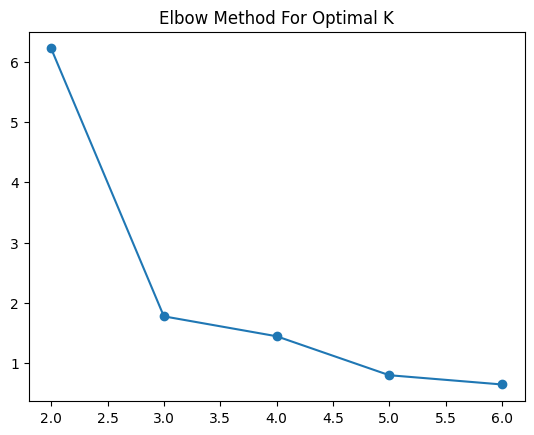

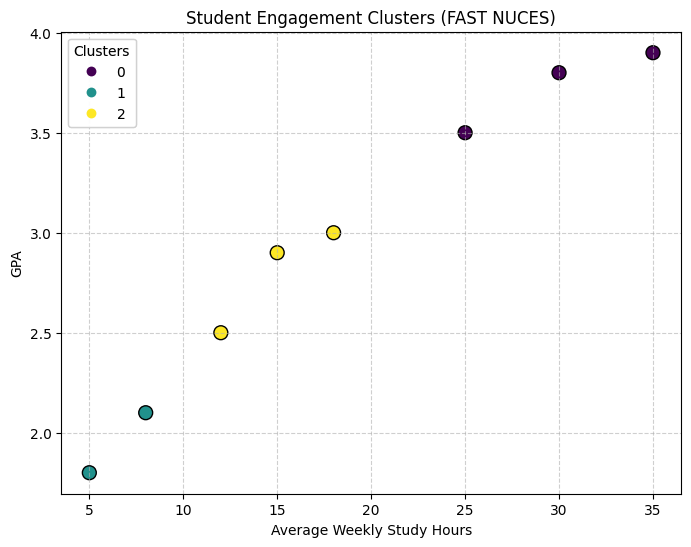


Final Dataset with Assigned Clusters:
  student_id  GPA  study_hours  attendance_rate  Cluster
0    K21-001  3.8           30               95        0
1    K21-002  2.1            8               60        1
2    K21-003  3.5           25               90        0
3    K21-004  1.8            5               50        1
4    K21-005  3.9           35               98        0
5    K21-006  2.5           12               70        2
6    K21-007  3.0           18               80        2
7    K21-008  2.9           15               75        2


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 1. Generate Mock Student Data
data_t3 = {
    'student_id': ['K21-001', 'K21-002', 'K21-003', 'K21-004', 'K21-005', 'K21-006', 'K21-007', 'K21-008'],
    'GPA': [3.8, 2.1, 3.5, 1.8, 3.9, 2.5, 3.0, 2.9],
    'study_hours': [30, 8, 25, 5, 35, 12, 18, 15],
    'attendance_rate': [95, 60, 90, 50, 98, 70, 80, 75]
}
df_students = pd.DataFrame(data_t3)

# 2. Feature Selection & Scaling
features = ['GPA', 'study_hours', 'attendance_rate']
X_stu = df_students[features]

scaler = StandardScaler()
X_stu_scaled = scaler.fit_transform(X_stu)

# 3. Determine Optimal K Using Elbow Method
inertias = []
K_range = range(2, 7)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_stu_scaled)
    inertias.append(km.inertia_)

# Plotting the Elbow Method
plt.plot(K_range, inertias, marker='o')
plt.title('Elbow Method For Optimal K')
# plt.show()

# Based on standard output, K=3 is usually the "elbow" point here.
optimal_k = 3

# 4. Perform Final Clustering
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
df_students['Cluster'] = kmeans_final.fit_predict(X_stu_scaled)

# 5. Visualization: Scatter Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_students['study_hours'], df_students['GPA'], 
                      c=df_students['Cluster'], cmap='viridis', s=100, edgecolor='k')

plt.title('Student Engagement Clusters (FAST NUCES)')
plt.xlabel('Average Weekly Study Hours')
plt.ylabel('GPA')

# Adding a legend
legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 6. Deliverables: Final Dataset
print("\nFinal Dataset with Assigned Clusters:")
print(df_students[['student_id', 'GPA', 'study_hours', 'attendance_rate', 'Cluster']])